1. Classification  
1.1 MNIST Classification
Dataset: MNIST Dataset
Task: Build a classical ML model to predict the input images into final class labels. Calculate all
the metrics such as accuracy, RoC, AUC, etc. Try different methods such as CNN, SVM, etc. to
compare the results.
1.2 Use VQA algorithms to enhance the classical model. Build different hybrid models,
combining both classical and quantum methods to test on the MNIST dataset. Calculate similar
metrics for these quantum and hybrid models as well.
Bonus: Participants can try extending their work to more complex classification datasets such as
the ChEMBL datasets for bioactivity classification or DDI (Drug-Drug Interation), PPI
(Protein-Protein Interaction) tasks, etc.

# **Convolutional Neural Network**

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

epochs = 10
batch_size = 64
lr = 0.001

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_load = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_load = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.drop = nn.Dropout(0.25)

        self.classifier = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.drop(x)
        x = self.classifier(x)
        return x

model = CNN().to(device)


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# use the pretrained model
model = torch.load('/content/mnist_cnn_model.pt')



# **Support Vector Machine**

Epoch 1/3 - Loss: 0.1784 - Acc: 0.9480
Epoch 2/3 - Loss: 0.0510 - Acc: 0.9846
Epoch 3/3 - Loss: 0.0373 - Acc: 0.9884

--- Extracting training features using CNN feature extractor ---
--- Extracting testing features using CNN feature extractor ---
Shape of training features: (60000, 3136)
Shape of training labels: (60000,)
Shape of testing features: (10000, 3136)
Shape of testing labels: (10000,)
Training SVM...
Accuracy (SVM on CNN features): 0.9910
Individual Class AUC
AUC for Class 0: 1.0000
AUC for Class 1: 1.0000
AUC for Class 2: 1.0000
AUC for Class 3: 1.0000
AUC for Class 4: 1.0000
AUC for Class 5: 0.9999
AUC for Class 6: 1.0000
AUC for Class 7: 1.0000
AUC for Class 8: 1.0000
AUC for Class 9: 0.9999


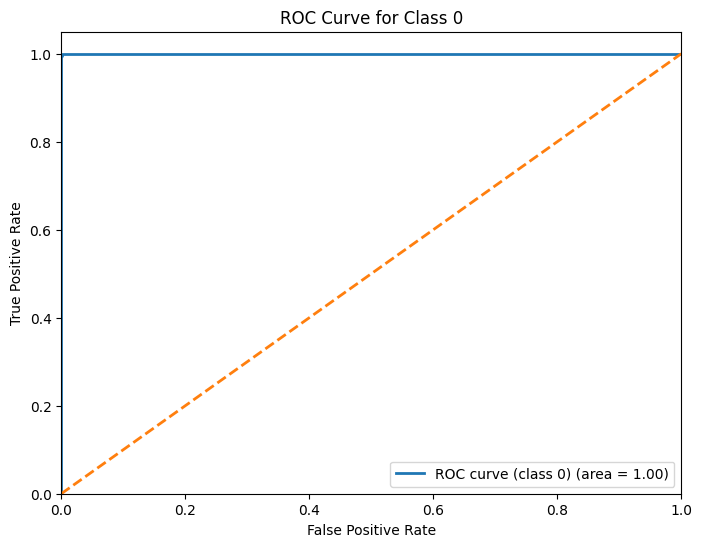

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparams
batch_size = 128
train_epochs = 3          # increase if you want better features
lr = 1e-3

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_load = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_load = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)


class CNNFeatureExtractor(nn.Module):
    def __init__(self):
        super(CNNFeatureExtractor, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return x


# Create feature extractor and a linear head for training
feature_extractor = CNNFeatureExtractor().to(device)
# Freeze? not necessary here; we train end-to-end
feat_dim = 64 * 7 * 7
classifier_head = nn.Linear(feat_dim, 10).to(device)

# Combined model for training convenience
class FullModel(nn.Module):
    def __init__(self, feat_ext, head):
        super().__init__()
        self.feat = feat_ext
        self.head = head
    def forward(self, x):
        f = self.feat(x)
        out = self.head(f)
        return out

model = FullModel(feature_extractor, classifier_head).to(device)

# Loss + optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# Train for a few epochs so the feature extractor learns something useful
model.train()
for epoch in range(train_epochs):
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_load:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f"Epoch {epoch+1}/{train_epochs} - Loss: {epoch_loss:.4f} - Acc: {epoch_acc:.4f}")

# Now use the trained feature extractor for feature extraction
feature_extractor.eval()

def extract_features(data_loader, model):
    all_features = []
    all_labels = []
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            features = model(images)
            all_features.append(features.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    return np.vstack(all_features), np.concatenate(all_labels)

print("\n--- Extracting training features using CNN feature extractor ---")
X_train, y_train = extract_features(train_load, feature_extractor)
print("--- Extracting testing features using CNN feature extractor ---")
X_test, y_test = extract_features(test_load, feature_extractor)

print(f"Shape of training features: {X_train.shape}")
print(f"Shape of training labels: {y_train.shape}")
print(f"Shape of testing features: {X_test.shape}")
print(f"Shape of testing labels: {y_test.shape}")

# Train SVM on features
print("Training SVM...")
svm_model = SVC(kernel='linear', random_state=42, probability=True)  # probability=True needed for predict_proba
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy (SVM on CNN features): {accuracy:.4f}')

# Use predict_proba for per-class AUC (guarantees shape (n_samples, n_classes))
y_proba = svm_model.predict_proba(X_test)  # shape (n_samples, n_classes)

# Ensure label binarizer uses the same class order as SVM
lb = LabelBinarizer()
lb.fit(svm_model.classes_)           # fit to ordered classes from the svm
y_test_one_hot = lb.transform(y_test)  # now columns align with y_proba columns

print("Individual Class AUC")
for i, cls in enumerate(svm_model.classes_):
    try:
        class_auc = roc_auc_score(y_test_one_hot[:, i], y_proba[:, i])
    except ValueError:
        class_auc = float('nan')  # if only one class present in test, AUC undefined
    print(f'AUC for Class {cls}: {class_auc:.4f}')

# Plot ROC for one class (example: class 0)
class_to_plot = 0
y_true_class_to_plot = (y_test == class_to_plot).astype(int)
# use the probability column for that class
y_score_class_to_plot = y_proba[:, list(svm_model.classes_).index(class_to_plot)]

fpr, tpr, _ = roc_curve(y_true_class_to_plot, y_score_class_to_plot)
plt.figure(figsize=(8, 6))
auc_val = roc_auc_score(y_true_class_to_plot, y_score_class_to_plot)
plt.plot(fpr, tpr, lw=2, label=f'ROC curve (class {class_to_plot}) (area = {auc_val:.2f})')
plt.plot([0, 1], [0, 1], lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve for Class {class_to_plot}')
plt.legend(loc="lower right")
plt.show()
